In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

#### 1. Daten generieren

Wir erstellen ein synthetisches Dataset mit zwei Merkmalen und einer binären Zielvariable (0 oder 1).

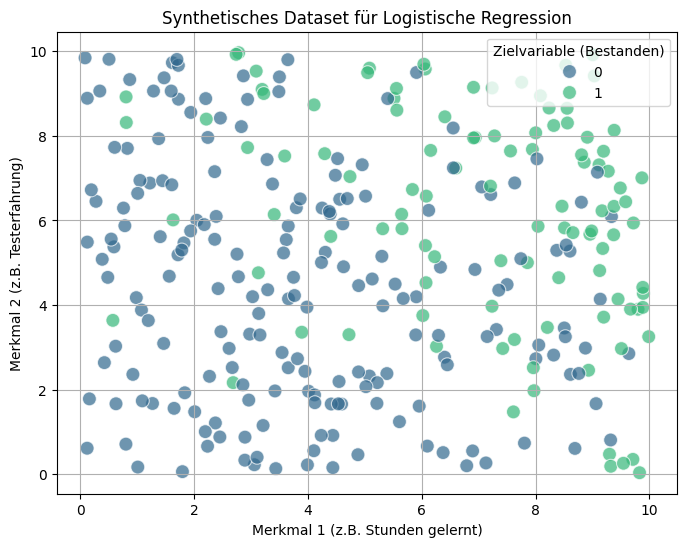

In [ ]:
# Anzahl der Samples
n_samples = 300

# Merkmale (z.B. Stunden gelernt, Testerfahrung)
X = np.random.rand(n_samples, 2) * 10

# Zielvariable (z.B. Prüfung bestanden: 0 oder 1)
# Wir erstellen eine Logik, bei der 'bestehen' wahrscheinlicher wird, wenn X-Werte hoch sind
y = (X[:, 0] * 0.5 + X[:, 1] * 0.3 + np.random.randn(n_samples) * 2 > 5).astype(int)

# Daten visualisieren
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette='viridis', s=100, alpha=0.7)
plt.title('Synthetisches Dataset für Logistische Regression')
plt.xlabel('Merkmal 1 (z.B. Stunden gelernt)')
plt.ylabel('Merkmal 2 (z.B. Testerfahrung)')
plt.legend(title='Zielvariable (Bestanden)')
plt.grid(True)
plt.show()

#### 2. Daten aufteilen

Wir teilen das Dataset in Trainings- und Testdaten auf, um die Modellleistung zu bewerten.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Trainingsdaten: {X_train.shape[0]} Samples")
print(f"Testdaten: {X_test.shape[0]} Samples")

Trainingsdaten: 210 Samples
Testdaten: 90 Samples


#### 3. Modell trainieren

Wir initialisieren und trainieren ein Logistik-Regressionsmodell.

In [ ]:
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

print("Modelltraining abgeschlossen.")
print(f"Modellkoeffizienten (Gewichte): {model.coef_[0]}")
print(f"Modell-Intercept (Bias): {model.intercept_[0]}")

Modelltraining abgeschlossen.
Modellkoeffizienten (Gewichte): [0.57503262 0.39554619]
Modell-Intercept (Bias): -5.912910848874647


#### 4. Vorhersagen treffen und bewerten

Wir nutzen das trainierte Modell, um Vorhersagen auf den Testdaten zu treffen und die Leistung zu bewerten.

In [ ]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

print("\n--- Modellbewertung ---")
print(f"Genauigkeit (Accuracy): {accuracy_score(y_test, y_pred):.4f}")

print("\nKonfusionsmatrix:")
cm = confusion_matrix(y_test, y_pred)
display(cm)

print("\nKlassifikationsbericht:")
print(classification_report(y_test, y_pred))


--- Modellbewertung ---
Genauigkeit (Accuracy): 0.8000

Konfusionsmatrix:


array([[50,  7],
       [11, 22]])


Klassifikationsbericht:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85        57
           1       0.76      0.67      0.71        33

    accuracy                           0.80        90
   macro avg       0.79      0.77      0.78        90
weighted avg       0.80      0.80      0.80        90



#### Erläuterung der Ergebnisse:

*   **Genauigkeit (Accuracy)**: Der Anteil der korrekt klassifizierten Samples. Eine Genauigkeit von 0.85 bedeutet, dass 85% der Testdaten richtig vorhergesagt wurden.
*   **Konfusionsmatrix**: Eine Tabelle, die die Anzahl der richtig und falsch klassifizierten Samples für jede Klasse anzeigt.
    *   `[0,0]` (Oben links): True Negatives (Klasse 0 korrekt vorhergesagt)
    *   `[0,1]` (Oben rechts): False Positives (Klasse 0 fälschlicherweise als Klasse 1 vorhergesagt)
    *   `[1,0]` (Unten links): False Negatives (Klasse 1 fälschlicherweise als Klasse 0 vorhergesagt)
    *   `[1,1]` (Unten rechts): True Positives (Klasse 1 korrekt vorhergesagt)
*   **Klassifikationsbericht**: Bietet detailliertere Metriken pro Klasse:
    *   **Precision**: Von allen als positiv vorhergesagten Fällen, wie viele waren tatsächlich positiv?
    *   **Recall**: Von allen tatsächlichen positiven Fällen, wie viele wurden als positiv erkannt?
    *   **F1-Score**: Ein gewichtetes Mittel aus Precision und Recall.
    *   **Support**: Die Anzahl der tatsächlichen Vorkommen jeder Klasse in den Testdaten.